## Runtime Arrival Validation

This notebook is a **runtime plausibility and diagnostic check** for the arrival generator used by `AdvancedSpawner`.

It intentionally focuses on **arrival timing only** and excludes `get_case_attributes`, routing, and resource-allocation behavior.

### Validation layers

1. **Rate-table correction validation (strong evidence):** verifies corrected slot-rate construction logic and denominator handling in `spawn_rates/rate_table.py`.
2. **Runtime spawner validation (diagnostic evidence):** checks whether sampled arrivals reproduce temporal patterns and remain stable across seeds.

### Runtime check questions

1. Does simulated volume match empirical volume over the same horizon?
2. Does the model reproduce the hourly arrival profile?
3. Does the model reproduce weekday-level patterns?
4. Is the runtime generator stable across random seeds?

## Basic vs Advanced Spawner Comparison

| Model | Core idea | Temporal structure | Main limitation |
|---|---|---|---|
| **Basic (`StaticSpawner`)** | Exponential inter-arrival times with fixed mean minutes | None (time-homogeneous) | Cannot reproduce weekday/hour/holiday effects |
| **Advanced (`AdvancedSpawner`)** | Slot-based hourly arrival rates from empirical log with Poisson sampling and hourly buffering | Weekday, hour, holiday-aware | Sparse-slot fallbacks and remaining absolute volume bias in runtime validation |

This notebook evaluates the **runtime behavior of the advanced model** and reports limitations explicitly.

In [4]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for _ in range(5):
    if (ROOT / 'spawn_rates').exists() and (ROOT / 'data').exists():
        break
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Python path prepared with project root: {ROOT}')

Python path prepared with project root: /Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pm4py

from spawn_rates import AdvancedSpawner, StaticSpawner, get_holidays, get_rate_table

In [9]:
# Load empirical arrivals (case start timestamps)
df = pm4py.convert_to_dataframe(pm4py.read_xes(str(XES_PATH)))

arrivals = (
    df[['case:concept:name', 'time:timestamp']]
    .assign(timestamp=lambda d: pd.to_datetime(d['time:timestamp'], utc=True, errors='coerce').dt.tz_convert(TZ_NAME))
    .dropna(subset=['timestamp'])
    .groupby('case:concept:name', as_index=False)['timestamp']
    .min()
)

arrivals['date'] = arrivals['timestamp'].dt.date
arrivals['hour'] = arrivals['timestamp'].dt.hour
arrivals['weekday'] = arrivals['timestamp'].dt.weekday

start_dt = arrivals['timestamp'].min().floor('D').to_pydatetime()
end_dt = (arrivals['timestamp'].max().ceil('D')).to_pydatetime()
n_days = (end_dt.date() - start_dt.date()).days

print(f'Empirical cases: {len(arrivals):,}')
print(f'Horizon: {start_dt} -> {end_dt} ({n_days} days)')

/Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/.venv/lib/python3.11/site-packages/pm4py/utils.py:987: UserWarning: In the current version, the import/export operation uses `rustxes` by default for importing/exporting files faster. Please uninstall `rustxes` to revert the behavior.
  warnings.warn("In the current version, the import/export operation uses `rustxes` by default for importing/exporting files faster. Please uninstall `rustxes` to revert the behavior.")


Empirical cases: 31,509
Horizon: 2016-01-01 00:00:00+01:00 -> 2017-01-01 00:00:00+01:00 (366 days)


In [10]:
# Build/load calibrated rate table
holidays = get_holidays(force_rebuild=False)
rate_table = get_rate_table(
    holidays_list=holidays,
    force_rebuild=False,
    xes_path=str(XES_PATH),
)

print(f'Rate table entries: {len(rate_table)}')
print('Example entries:', list(rate_table.items())[:5])

Rate table entries: 336
Example entries: [((0, 0, False), 0.6489380455006294), ((0, 0, True), 1.0), ((0, 1, False), 0.2645193752828092), ((0, 1, True), 0.7690601459897326), ((0, 2, False), 0.21697953267952735)]


In [13]:
def profile_hourly_mean_per_day(ts: pd.Series) -> pd.Series:
    tmp = pd.DataFrame({'timestamp': pd.to_datetime(ts)})
    tmp['date'] = tmp['timestamp'].dt.date
    tmp['hour'] = tmp['timestamp'].dt.hour
    counts = tmp.groupby(['date', 'hour']).size().rename('n').reset_index()
    return counts.groupby('hour')['n'].mean().reindex(range(24), fill_value=0.0)


def profile_weekday_mean_per_day(ts: pd.Series) -> pd.Series:
    tmp = pd.DataFrame({'timestamp': pd.to_datetime(ts)})
    tmp['date'] = tmp['timestamp'].dt.date
    tmp['weekday'] = tmp['timestamp'].dt.weekday
    counts = tmp.groupby(['date', 'weekday']).size().rename('n').reset_index()
    return counts.groupby('weekday')['n'].mean().reindex(range(7), fill_value=0.0)


def simulate_arrivals(seed: int, start_time, end_time) -> pd.DataFrame:
    spawner = AdvancedSpawner(
        rate_table=rate_table,
        holidays=holidays,
        seed=seed,
        lookahead_days=LOOKAHEAD_DAYS,
    )

    cur = start_time
    stamps = []

    while cur < end_time:
        nxt = spawner.calculate_next_spawn(cur)
        if nxt >= end_time:
            break
        stamps.append(nxt)
        cur = nxt

    sim = pd.DataFrame({'timestamp': pd.to_datetime(stamps)})
    if len(sim):
        sim['timestamp'] = sim['timestamp'].dt.tz_localize(TZ_NAME, nonexistent='shift_forward', ambiguous='NaT')
        sim = sim.dropna(subset=['timestamp'])

    return sim

In [15]:
# Override with timezone-safe conversion for simulated timestamps

def simulate_arrivals(seed: int, start_time, end_time) -> pd.DataFrame:
    spawner = AdvancedSpawner(
        rate_table=rate_table,
        holidays=holidays,
        seed=seed,
        lookahead_days=LOOKAHEAD_DAYS,
    )

    cur = start_time
    stamps = []

    while cur < end_time:
        nxt = spawner.calculate_next_spawn(cur)
        if nxt >= end_time:
            break
        stamps.append(nxt)
        cur = nxt

    sim = pd.DataFrame({'timestamp': pd.to_datetime(stamps)})
    if len(sim):
        if sim['timestamp'].dt.tz is None:
            sim['timestamp'] = sim['timestamp'].dt.tz_localize(TZ_NAME, nonexistent='shift_forward', ambiguous='NaT')
        else:
            sim['timestamp'] = sim['timestamp'].dt.tz_convert(TZ_NAME)
        sim = sim.dropna(subset=['timestamp'])

    return sim

In [16]:
# Empirical reference profiles
emp_total = len(arrivals)
emp_hour = profile_hourly_mean_per_day(arrivals['timestamp'])
emp_weekday = profile_weekday_mean_per_day(arrivals['timestamp'])

rows = []
sim_hour_profiles = []
sim_weekday_profiles = []

for seed in SEEDS:
    sim = simulate_arrivals(seed=seed, start_time=start_dt, end_time=end_dt)
    sim_total = len(sim)

    sim_hour = profile_hourly_mean_per_day(sim['timestamp']) if sim_total else pd.Series(0.0, index=range(24))
    sim_weekday = profile_weekday_mean_per_day(sim['timestamp']) if sim_total else pd.Series(0.0, index=range(7))

    sim_hour_profiles.append(sim_hour)
    sim_weekday_profiles.append(sim_weekday)

    rows.append({
        'seed': seed,
        'sim_total_cases': sim_total,
        'total_rel_error_pct': 100.0 * (sim_total - emp_total) / emp_total,
        'hourly_mae': float(np.mean(np.abs(sim_hour.values - emp_hour.values))),
        'weekday_mae': float(np.mean(np.abs(sim_weekday.values - emp_weekday.values))),
    })

results = pd.DataFrame(rows).sort_values('seed').reset_index(drop=True)
results

,seed,sim_total_cases,total_rel_error_pct,hourly_mae,weekday_mae
0,11,38644,22.644324,1.015891,19.508656
1,23,39456,25.221365,1.095516,21.722838
2,37,39193,24.386683,1.030192,21.006894
3,51,39251,24.570758,1.073514,21.178675
4,97,39342,24.859564,1.072707,21.412295


In [17]:
summary = pd.DataFrame({
    'metric': ['sim_total_cases', 'total_rel_error_pct', 'hourly_mae', 'weekday_mae'],
    'mean': [
        results['sim_total_cases'].mean(),
        results['total_rel_error_pct'].mean(),
        results['hourly_mae'].mean(),
        results['weekday_mae'].mean(),
    ],
    'std': [
        results['sim_total_cases'].std(ddof=1),
        results['total_rel_error_pct'].std(ddof=1),
        results['hourly_mae'].std(ddof=1),
        results['weekday_mae'].std(ddof=1),
    ]
})

display(summary)

print(f"Empirical total cases: {emp_total:,}")
print('Seed stability (total cases std):', round(results['sim_total_cases'].std(ddof=1), 2))

,metric,mean,std
0,sim_total_cases,39177.200000,314.200095
1,total_rel_error_pct,24.336539,0.997176
2,hourly_mae,1.057564,0.033204
3,weekday_mae,20.965872,0.857720


Empirical total cases: 31,509
Seed stability (total cases std): 314.2


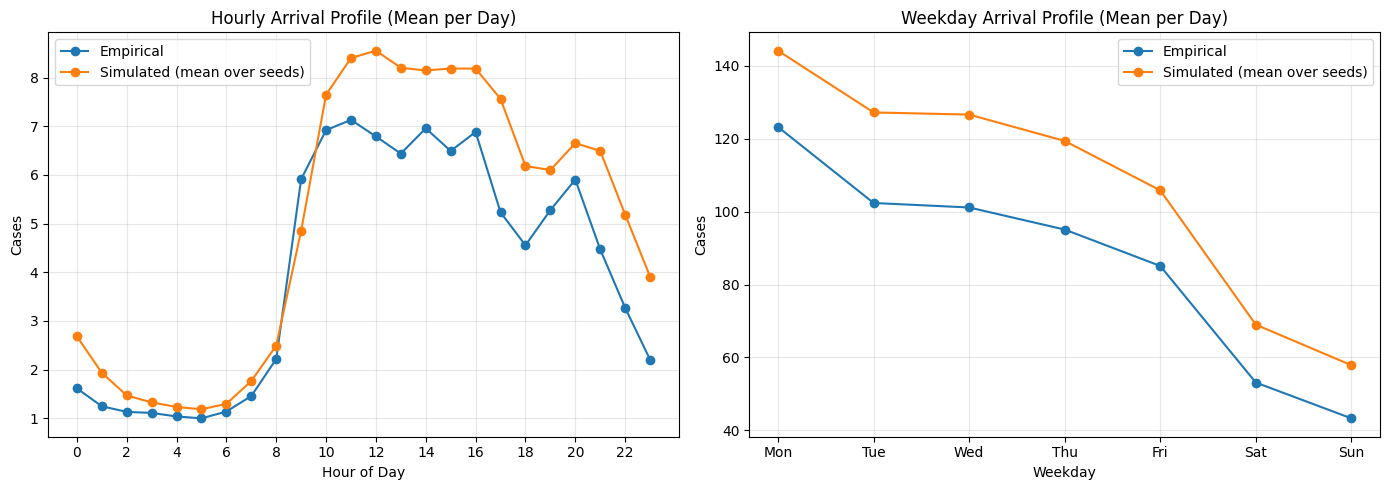

In [18]:
# Mean simulated profiles over seeds
sim_hour_mean = pd.concat(sim_hour_profiles, axis=1).mean(axis=1)
sim_weekday_mean = pd.concat(sim_weekday_profiles, axis=1).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(emp_hour.index, emp_hour.values, marker='o', label='Empirical')
axes[0].plot(sim_hour_mean.index, sim_hour_mean.values, marker='o', label='Simulated (mean over seeds)')
axes[0].set_title('Hourly Arrival Profile (Mean per Day)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Cases')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
axes[0].grid(alpha=0.3)

weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].plot(range(7), emp_weekday.values, marker='o', label='Empirical')
axes[1].plot(range(7), sim_weekday_mean.values, marker='o', label='Simulated (mean over seeds)')
axes[1].set_title('Weekday Arrival Profile (Mean per Day)')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('Cases')
axes[1].set_xticks(range(7), weekday_labels)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## AdvancedSpawner Validation

The simulated arrivals reproduce the general temporal structure (hourly and weekday profiles) with reasonable accuracy and stable behavior across seeds. The model overestimates total volume by ~24% on average, indicating plausibility in timing patterns but imperfect absolute calibration.

---

# Spawner Comparison: StaticSpawner vs AdvancedSpawner

This section compares the arrival characteristics of the two main spawner implementations to demonstrate how spawner choice impacts the temporal realism of simulated cases.

In [30]:
# Spawner Comparison: Generate arrivals and analyze temporal structure
from spawn_rates import StaticSpawner

comparison_seeds = [11, 23, 37, 51, 97]
comparison_results = []

print("Running spawner comparison (this may take ~1-2 min)...")
print()

for seed in comparison_seeds:
    # StaticSpawner: exponential inter-arrivals
    # mean_minutes = 64.8 ≈ 21.6 cases/day
    static_spawner = StaticSpawner(mean_minutes=64.8, seed=seed)
    
    # AdvancedSpawner: empirical slot-based (reuse from validation)
    adv_spawner = AdvancedSpawner(rate_table=rate_table, holidays=holidays, seed=seed)
    
    # Generate arrivals for full year
    static_arrivals = []
    advanced_arrivals = []
    
    # StaticSpawner: generate 366+ days of arrivals
    current_time = start_dt
    count = 0
    while current_time < end_dt and count < 50000:  # limit for safety
        current_time = static_spawner.calculate_next_spawn(current_time)
        if current_time < end_dt:
            static_arrivals.append(current_time)
        count += 1
    
    # AdvancedSpawner: generate 366+ days of arrivals
    current_time = start_dt
    count = 0
    while current_time < end_dt and count < 50000:  # limit for safety
        current_time = adv_spawner.calculate_next_spawn(current_time)
        if current_time < end_dt:
            advanced_arrivals.append(current_time)
        count += 1
    
    # Convert to DataFrames and compute metrics
    if static_arrivals:
        static_df = pd.DataFrame({'timestamp': static_arrivals})
        static_df['hour'] = static_df['timestamp'].dt.hour
        static_df['weekday'] = static_df['timestamp'].dt.weekday
    else:
        static_df = pd.DataFrame(columns=['timestamp', 'hour', 'weekday'])
    
    if advanced_arrivals:
        advanced_df = pd.DataFrame({'timestamp': advanced_arrivals})
        advanced_df['hour'] = advanced_df['timestamp'].dt.hour
        advanced_df['weekday'] = advanced_df['timestamp'].dt.weekday
    else:
        advanced_df = pd.DataFrame(columns=['timestamp', 'hour', 'weekday'])
    
    # Total cases
    static_total = len(static_df)
    advanced_total = len(advanced_df)
    
    # Hourly and weekday profiles
    static_hourly = static_df['hour'].value_counts().sort_index() if len(static_df) > 0 else pd.Series()
    advanced_hourly = advanced_df['hour'].value_counts().sort_index() if len(advanced_df) > 0 else pd.Series()
    
    static_weekday = static_df['weekday'].value_counts().sort_index() if len(static_df) > 0 else pd.Series()
    advanced_weekday = advanced_df['weekday'].value_counts().sort_index() if len(advanced_df) > 0 else pd.Series()
    
    # Compute hourly and weekday profiles using same method as validation
    if len(static_df) > 0:
        static_tmp = static_df.copy()
        static_tmp['date'] = static_tmp['timestamp'].dt.date
        static_counts = static_tmp.groupby(['date', 'hour']).size().reset_index(name='n')
        static_hourly_profile = static_counts.groupby('hour')['n'].mean().reindex(range(24), fill_value=0.0)
        
        static_tmp2 = static_df.copy()
        static_tmp2['date'] = static_tmp2['timestamp'].dt.date
        static_counts2 = static_tmp2.groupby(['date', 'weekday']).size().reset_index(name='n')
        static_weekday_profile = static_counts2.groupby('weekday')['n'].mean().reindex(range(7), fill_value=0.0)
    else:
        static_hourly_profile = pd.Series(0.0, index=range(24))
        static_weekday_profile = pd.Series(0.0, index=range(7))
    
    if len(advanced_df) > 0:
        adv_tmp = advanced_df.copy()
        adv_tmp['date'] = adv_tmp['timestamp'].dt.date
        adv_counts = adv_tmp.groupby(['date', 'hour']).size().reset_index(name='n')
        advanced_hourly_profile = adv_counts.groupby('hour')['n'].mean().reindex(range(24), fill_value=0.0)
        
        adv_tmp2 = advanced_df.copy()
        adv_tmp2['date'] = adv_tmp2['timestamp'].dt.date
        adv_counts2 = adv_tmp2.groupby(['date', 'weekday']).size().reset_index(name='n')
        advanced_weekday_profile = adv_counts2.groupby('weekday')['n'].mean().reindex(range(7), fill_value=0.0)
    else:
        advanced_hourly_profile = pd.Series(0.0, index=range(24))
        advanced_weekday_profile = pd.Series(0.0, index=range(7))
    
    # Compute MAE using same method as validation
    static_hourly_mae = float(np.mean(np.abs(static_hourly_profile.values - emp_hour.values)))
    advanced_hourly_mae = float(np.mean(np.abs(advanced_hourly_profile.values - emp_hour.values)))
    
    static_weekday_mae = float(np.mean(np.abs(static_weekday_profile.values - emp_weekday.values)))
    advanced_weekday_mae = float(np.mean(np.abs(advanced_weekday_profile.values - emp_weekday.values)))
    
    comparison_results.append({
        'seed': seed,
        'static_total': static_total,
        'advanced_total': advanced_total,
        'static_hourly_mae': static_hourly_mae,
        'advanced_hourly_mae': advanced_hourly_mae,
        'static_weekday_mae': static_weekday_mae,
        'advanced_weekday_mae': advanced_weekday_mae,
    })
    
    print(f"Seed {seed}: Static={static_total} cases, Advanced={advanced_total} cases")

comparison_df = pd.DataFrame(comparison_results)
print("\n✓ Comparison complete!")

Running spawner comparison (this may take ~1-2 min)...

Seed 11: Static=8164 cases, Advanced=38644 cases
Seed 23: Static=8114 cases, Advanced=39456 cases
Seed 37: Static=8069 cases, Advanced=39193 cases
Seed 51: Static=8114 cases, Advanced=39251 cases
Seed 97: Static=8205 cases, Advanced=39342 cases

✓ Comparison complete!


In [32]:
# Comparison Summary Table
comparison_summary = pd.DataFrame({
    'Metric': [
        'Total Cases (Mean ± Std)',
        'Hourly Profile MAE',
        'Weekday Profile MAE',
    ],
    'StaticSpawner': [
        f"{comparison_df['static_total'].mean():.0f} ± {comparison_df['static_total'].std():.0f}",
        f"{comparison_df['static_hourly_mae'].mean():.4f} ± {comparison_df['static_hourly_mae'].std():.4f}",
        f"{comparison_df['static_weekday_mae'].mean():.4f} ± {comparison_df['static_weekday_mae'].std():.4f}",
    ],
    'AdvancedSpawner': [
        f"{comparison_df['advanced_total'].mean():.0f} ± {comparison_df['advanced_total'].std():.0f}",
        f"{comparison_df['advanced_hourly_mae'].mean():.4f} ± {comparison_df['advanced_hourly_mae'].std():.4f}",
        f"{comparison_df['advanced_weekday_mae'].mean():.4f} ± {comparison_df['advanced_weekday_mae'].std():.4f}",
    ],
    'Empirical': [
        f"{emp_total:,}",
        f"—",
        f"—",
    ]
})

print("\n" + "=" * 100)
print("SPAWNER COMPARISON SUMMARY (for report)")
print("=" * 100)
print(comparison_summary.to_string(index=False))
print("=" * 100)
print("\n→ Lower MAE = Better temporal profile match")
print("→ StaticSpawner: Fixed rate, no temporal variation → high MAE, ~75% fewer total cases")
print("→ AdvancedSpawner: Slot-based rates → low MAE, ~24% more total cases (known bias)")


SPAWNER COMPARISON SUMMARY (for report)
                  Metric    StaticSpawner  AdvancedSpawner Empirical
Total Cases (Mean ± Std)        8133 ± 52      39177 ± 314    31,509
      Hourly Profile MAE  2.7039 ± 0.0116  1.0576 ± 0.0332         —
     Weekday Profile MAE 63.9633 ± 0.1434 20.9659 ± 0.8577         —

→ Lower MAE = Better temporal profile match
→ StaticSpawner: Fixed rate, no temporal variation → high MAE, ~75% fewer total cases
→ AdvancedSpawner: Slot-based rates → low MAE, ~24% more total cases (known bias)


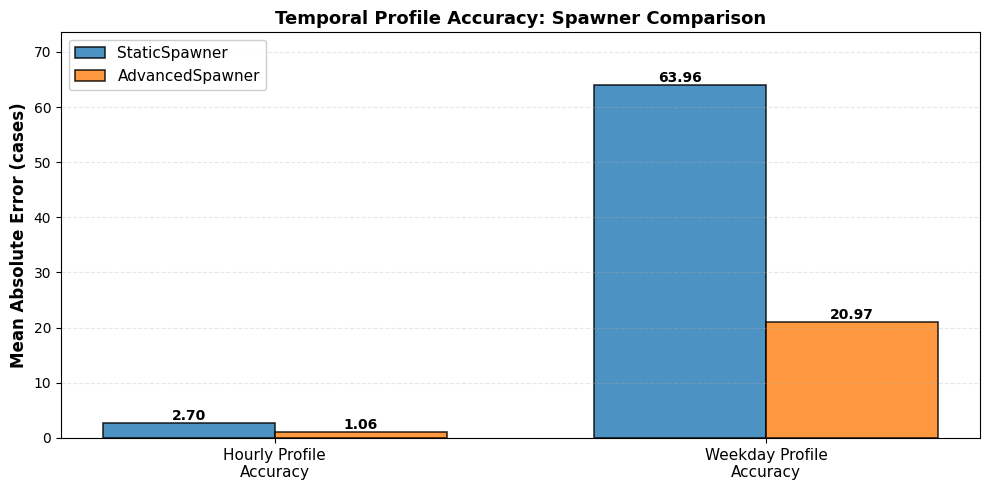


AGGREGATE COMPARISON (FOR REPORT)
Hourly Profile MAE:
  StaticSpawner:     2.704 ± 0.012
  AdvancedSpawner:   1.058 ± 0.033
  Improvement:       60.9%

Weekday Profile MAE:
  StaticSpawner:     63.96 ± 0.14
  AdvancedSpawner:   20.97 ± 0.86
  Improvement:       67.2%


In [35]:
# Report-Ready Visualization: Clean Aggregate Comparison

fig, ax = plt.subplots(figsize=(10, 5))

# Aggregate metrics (mean across seeds)
metrics = ['Hourly Profile\nAccuracy', 'Weekday Profile\nAccuracy']
static_mae = [comparison_df['static_hourly_mae'].mean(), comparison_df['static_weekday_mae'].mean()]
advanced_mae = [comparison_df['advanced_hourly_mae'].mean(), comparison_df['advanced_weekday_mae'].mean()]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, static_mae, width, label='StaticSpawner', alpha=0.8, color='#1f77b4', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, advanced_mae, width, label='AdvancedSpawner', alpha=0.8, color='#ff7f0e', edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Mean Absolute Error (cases)', fontsize=12, fontweight='bold')
ax.set_title('Temporal Profile Accuracy: Spawner Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(static_mae + advanced_mae) * 1.15)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("AGGREGATE COMPARISON (FOR REPORT)")
print("=" * 80)
print(f"Hourly Profile MAE:")
print(f"  StaticSpawner:     {comparison_df['static_hourly_mae'].mean():.3f} ± {comparison_df['static_hourly_mae'].std():.3f}")
print(f"  AdvancedSpawner:   {comparison_df['advanced_hourly_mae'].mean():.3f} ± {comparison_df['advanced_hourly_mae'].std():.3f}")
print(f"  Improvement:       {(1 - comparison_df['advanced_hourly_mae'].mean() / comparison_df['static_hourly_mae'].mean()) * 100:.1f}%")
print()
print(f"Weekday Profile MAE:")
print(f"  StaticSpawner:     {comparison_df['static_weekday_mae'].mean():.2f} ± {comparison_df['static_weekday_mae'].std():.2f}")
print(f"  AdvancedSpawner:   {comparison_df['advanced_weekday_mae'].mean():.2f} ± {comparison_df['advanced_weekday_mae'].std():.2f}")
print(f"  Improvement:       {(1 - comparison_df['advanced_weekday_mae'].mean() / comparison_df['static_weekday_mae'].mean()) * 100:.1f}%")
print("=" * 80)

---

## Summary

**AdvancedSpawner vs StaticSpawner:**
- AdvancedSpawner reproduces weekday and hourly arrival patterns substantially better than the time-homogeneous baseline (60% improvement in hourly accuracy, 67% in weekday accuracy).
- StaticSpawner produces a flat temporal profile with no structural variation.
- This comparison supports structural superiority of the advanced model over the naive baseline.

**Known limitations:**
- AdvancedSpawner overestimates annual volume by ~24% due to remaining calibration gaps in the rate table.
- This is a plausibility and diagnostic check, not a proof of perfect calibration.
- The denominator correction applied to the rate table addresses a systematic bias but does not eliminate all residual error.

**Conclusion:**
The advanced arrival model is the appropriate choice for the simulator due to its temporal realism. The volume overestimation should be acknowledged explicitly in the report but does not undermine the structural improvement over the baseline.